<h1 align="center">Allen/Neural Dynamics - Conect Hackathon</h1>  
<h4 align="center"> May 20, 2026 </h4>   
<h4 align="center"> Dynamic Routing</h4> 
    

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px">

**Overview:** In this notebook, we will analyze behavior and neural activity during flexible sensorimotor decision-making using a dataset from the [Dynamic Routing](https://www.allenneuraldynamics.org/projects/dynamic-routing) project at the Allen Institute/Neural Dynamics. This dataset provides a unique window into how distributed brain circuits reconfigure when the same animal must switch, in blocks of trials, between looking for a rewarded visual target and listening for a rewarded auditory target. This tutorial focuses on trial structure and task context, blockwise behavioral performance, region-level unit coverage, and trial-aligned neural and behavioral covariates in one representative Neuropixels session.
 
**Dataset:** 
Neural activity was recorded from head-fixed mice using 5–6 probes per 
session, in a broad set of hippocampal, striatal, thalamic, midbrain and cortical
structures, including frontal, somatosensory, prefrontal, visual, auditory, and temporal 
association cortices. The capsule contains five Neuropixels recording sessions from five 
different mice. Three of the five mouse lines express channelrhodopsin (ChR2) in genetically 
defined inhibitory interneuron classes (Pvalb, Sst, or Vip) or in all GABAergic neurons (VGAT), 
enabling optotagging of those cell types; one mouse is wild-type. A total of 6,685 QC-passing units were recorded across the five 
sessions. Auditory and visual receptive field mapping are included, as well epochs in which no stimuli were presented, for exploring spontaneous activity in the brain. Each session also includes simultaneously acquired behavioral signals (licks, running 
speed, pupil area, eye tracking, face and body movements), all packaged in the 
Neurodata Without Borders (NWB) format and stored as cloud-friendly Zarr assets.

 **Experiment:**
 The task in the main `DynamicRouting1` epoch was designed to explore flexible neuronal communication. In visual-rewarded blocks, mice should respond by licking on trials that present the visual target stimulus (go: `vis1`), while withholding licking on trials with the auditory target and or non-target stimuli (no-go: `sound1`, `vis2`, `sound2`); after 10 minutes, the block switches to auditory-rewarded, and the target mapping reverses: `sound1` becomes the new go stimulus. Because the same sensory inputs can signal "go" in one block and "no-go" in another, stimulus identity is separated from task meaning, enabling analysis of how context shapes neural responses.
    
**Goal:** This tutorial will cover data access, details of the experiment, exploration and scientific analysis. <br>

  We will:
  1. Find & load data packaged as NWB files <br> 
  2. Explain the design of the Dynamic Routing task <br>
  3. Calculate behavioral performance metrics <br> 
  4. Summarize the brain areas recorded <br>
  5. Explore data around stimulus onset: neural activity, running speed, face motion <br>

In [9]:
from __future__ import annotations

import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import lazynwb

sys.path.insert(0, str(pathlib.Path.cwd()))
sys.path.insert(0, str(pathlib.Path.cwd() / "code"))

import nwb_access
import unit_raster_psth_plot

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

lazynwb.config.anon = True

UNIT_ID = "668755_2023-08-31_B-213" # context encoding, worse behavior
UNIT_ID = "713655_2024-08-09_E-167" # great behavior
SESSION_ID = UNIT_ID.removesuffix(f"_{UNIT_ID.split('_')[-1]}")
USE_ZARR = True

COLORS = {
    "black": "#000000",
    "white": "#FFFFFF",
    "gray2": "#737373",
    "page2": "#DED9D1",
    "blue": "#6464FF",
    "maroon": "#CD0F55",
}
CONTEXT_COLORS = {"vis": COLORS["blue"], "aud": COLORS["maroon"]}

plt.rcParams.update(
    {
        "figure.facecolor": COLORS["white"],
        "axes.facecolor": COLORS["white"],
        "axes.edgecolor": COLORS["black"],
        "axes.labelcolor": COLORS["black"],
        "xtick.color": COLORS["gray2"],
        "ytick.color": COLORS["gray2"],
        "grid.color": COLORS["page2"],
        "text.color": COLORS["black"],
        "font.family": ["Allen Institute Text", "Arial", "sans-serif"],
        "font.size": 9,
    }
)

# Set polars options for better notebook display
pl.Config.set_fmt_str_lengths(10_000).set_tbl_width_chars(-1)
pl.Config.set_tbl_rows(12)


polars.config.Config

---

## Metadata (from docdb/jsons)

In [10]:
pl.read_csv('metadata.csv')

subject_id,date,duration,type,modality_abbreviations,tags,name,project_name,investigators,nwb_path
i64,str,f64,str,str,str,str,str,str,str
664851,"""2023-11-15""",6867.392,"""brainwide survey""","""ecephys; behavior; behavior-videos""","""prod; first_block_aud; late_autorewards""","""ecephys_664851_2023-11-15_12-38-21_nwb_2026-05-01_13-18-55""","""Dynamic Routing""","""Shawn Olsen; Corbett Bennett""","""/root/capsule/data/ecephys_664851_2023-11-15_12-38-21_nwb_2026-05-01_13-18-55/664851_2023-11-15.nwb.zarr"""
668755,"""2023-08-31""",6973.718,"""brainwide survey""","""ecephys; behavior; behavior-videos""","""prod; first_block_vis; late_autorewards""","""ecephys_668755_2023-08-31_12-33-31_nwb_2026-05-01_13-19-39""","""Dynamic Routing""","""Shawn Olsen; Corbett Bennett""","""/root/capsule/data/ecephys_668755_2023-08-31_12-33-31_nwb_2026-05-01_13-19-39/668755_2023-08-31.nwb.zarr"""
713655,"""2024-08-09""",7685.58,"""brainwide survey""","""ecephys; behavior; behavior-videos""","""prod; first_block_aud; late_autorewards""","""ecephys_713655_2024-08-09_10-41-47_nwb_2026-05-01_13-21-04""","""Dynamic Routing""","""Shawn Olsen; Corbett Bennett""","""/root/capsule/data/ecephys_713655_2024-08-09_10-41-47_nwb_2026-05-01_13-21-04/713655_2024-08-09.nwb.zarr"""
759434,"""2025-02-04""",7029.242,"""brainwide survey""","""ecephys; behavior; behavior-videos""","""prod; first_block_vis; late_autorewards""","""ecephys_759434_2025-02-04_12-27-22_nwb_2026-05-01_13-17-10""","""Dynamic Routing""","""Shawn Olsen; Corbett Bennett""","""/root/capsule/data/ecephys_759434_2025-02-04_12-27-22_nwb_2026-05-01_13-17-10/759434_2025-02-04.nwb.zarr"""


## NWB file inventory

In [11]:
zarr_assets = (
    pl.DataFrame(nwb_access.load_assets(zarr=USE_ZARR))
    .with_columns(
        session_id=pl.col("nwb_path").str.extract(r"([^/]+)\.nwb\.zarr$", 1)
    )
    .select("session_id", "mount", "nwb_path")
)

session_nwb_path = nwb_access.get_session_nwb_path(SESSION_ID, zarr=USE_ZARR)
print(f"Using {SESSION_ID}: {session_nwb_path}")
zarr_assets


Using 713655_2024-08-09: s3://aind-open-data/ecephys_713655_2024-08-09_10-41-47_nwb_2026-05-07_14-00-54/713655_2024-08-09.nwb.zarr


session_id,mount,nwb_path
str,str,str
"""664851_2023-11-15""","""ecephys_664851_2023-11-15_12-38-21_nwb_2026-05-07_13-58-17""","""s3://aind-open-data/ecephys_664851_2023-11-15_12-38-21_nwb_2026-05-07_13-58-17/664851_2023-11-15.nwb.zarr"""
"""759434_2025-02-04""","""ecephys_759434_2025-02-04_12-27-22_nwb_2026-05-07_13-56-38""","""s3://aind-open-data/ecephys_759434_2025-02-04_12-27-22_nwb_2026-05-07_13-56-38/759434_2025-02-04.nwb.zarr"""
"""742903_2024-10-22""","""ecephys_742903_2024-10-22_10-58-35_nwb_2026-05-07_14-03-02""","""s3://aind-open-data/ecephys_742903_2024-10-22_10-58-35_nwb_2026-05-07_14-03-02/742903_2024-10-22.nwb.zarr"""
"""668755_2023-08-31""","""ecephys_668755_2023-08-31_12-33-31_nwb_2026-05-07_13-59-48""","""s3://aind-open-data/ecephys_668755_2023-08-31_12-33-31_nwb_2026-05-07_13-59-48/668755_2023-08-31.nwb.zarr"""
"""713655_2024-08-09""","""ecephys_713655_2024-08-09_10-41-47_nwb_2026-05-07_14-00-54""","""s3://aind-open-data/ecephys_713655_2024-08-09_10-41-47_nwb_2026-05-07_14-00-54/713655_2024-08-09.nwb.zarr"""


## Contents of an NWB file

In [12]:
lazynwb.get_internal_paths(session_nwb_path)

['/acquisition/frametimes_eye_camera',
 '/acquisition/frametimes_front_camera',
 '/acquisition/frametimes_side_camera',
 '/acquisition/manipulator_positions',
 '/intervals/aud_rf_mapping_trials',
 '/intervals/epochs',
 '/intervals/optotagging_trials',
 '/intervals/performance',
 '/intervals/trials',
 '/intervals/vis_rf_mapping_trials',
 '/processing/behavior/dlc_eye_camera',
 '/processing/behavior/eye_tracking',
 '/processing/behavior/facemap_front_camera',
 '/processing/behavior/facemap_side_camera',
 '/processing/behavior/licks',
 '/processing/behavior/lp_front_camera',
 '/processing/behavior/lp_side_camera',
 '/processing/behavior/quiescent_interval_violations',
 '/processing/behavior/rewards',
 '/processing/behavior/running_speed',
 '/units']

## Epochs in a session

In [13]:
nwb_access.scan_table("/intervals/epochs", session_id=SESSION_ID, zarr=USE_ZARR).drop(pl.selectors.starts_with("_")).collect()

id,interval_names,notes,script_name,start_time,stop_time,tags
i64,list[str],str,str,f64,f64,list[str]
0,"[""vis_rf_mapping_trials"", ""aud_rf_mapping_trials""]","""""","""RFMapping""",46.87727,917.574335,"[""mapping""]"
1,"[""optotagging_trials""]","""""","""OptoTagging""",928.21521,1163.07873,"[""optotagging""]"
2,"[""spontaneous_trials""]","""""","""Spontaneous""",1172.33761,1775.40866,"[""spontaneous""]"
3,"[""spontaneous_rewards_trials""]","""""","""SpontaneousRewards""",1786.10099,2389.106525,"[""rewards"", ""spontaneous""]"
4,"[""trials"", ""performance""]","""""","""DynamicRouting1""",2399.66534,6207.87263,"[""task"", ""rewards""]"
5,"[""spontaneous_rewards_trials""]","""""","""SpontaneousRewards""",6218.61508,6821.712065,"[""rewards"", ""spontaneous""]"
6,"[""spontaneous_trials""]","""""","""Spontaneous""",6832.42935,7435.551225,"[""spontaneous""]"
7,"[""optotagging_trials""]","""""","""OptoTagging""",7445.50961,7679.2554,"[""optotagging""]"


---
# `DynamicRouting1` task
## Trials table

NWB columns carry useful descriptions in their metadata, including column descriptions:


In [14]:
TRIAL_COLUMNS = [
    "trial_index",
    "block_index",
    "trial_index_in_block",
    "stim_name",
    "rewarded_modality",
    "is_instruction",
    "is_reward_scheduled",
    "is_contingent_reward",
    "is_noncontingent_reward",
    "is_response",
    "is_hit",
    "is_correct_reject",
    "is_false_alarm",
    "is_miss",
    "is_catch",
    "is_vis_stim",
    "is_aud_stim",
    "is_vis_target",
    "is_aud_target",
    "is_go",
    "is_nogo",
    "is_opto",
    "start_time",
    "stop_time",
    "stim_start_time",
    "stim_stop_time",
    "quiescent_start_time",
    "quiescent_stop_time",
    "response_window_start_time",
    "response_window_stop_time",
    "post_response_window_start_time",
    "post_response_window_stop_time",
    "response_time",
    "reward_time",
]

trial_column_descriptions = nwb_access.get_table_column_descriptions(
    "/intervals/trials",
    session_id=SESSION_ID,
    columns=TRIAL_COLUMNS,
)

trial_column_descriptions


{'trial_index': '0-indexed trial number',
 'block_index': '0-indexed block number, increments with each block',
 'stim_name': 'the stimulus presented; corresponds to a unique stimulus definition, randomized over trials',
 'rewarded_modality': 'indicates the name of the rewarded modality in each block; not an exact correspondence with the values in `stim_name`',
 'is_instruction': 'the stimulus presented was not random, but specifically chosen to inform the subject of a change in the rewarded stimulus modality (context)',
 'is_reward_scheduled': 'a non-contingent reward was scheduled to occur, regardless of whether it was delivered; the subject may have responded correctly and received a contingent reward instead',
 'is_contingent_reward': 'the subject received a reward for a correct response',
 'is_noncontingent_reward': 'the subject received a reward that did not depend on its response',
 'is_response': 'the subject licked one or more times during the response window',
 'is_hit': 'the

In [15]:
trials = (
    nwb_access.scan_table("/intervals/trials", session_id=SESSION_ID)
    .select(TRIAL_COLUMNS)
    .collect()
)
display(trials)

trial_index,block_index,trial_index_in_block,stim_name,rewarded_modality,is_instruction,is_reward_scheduled,is_contingent_reward,is_noncontingent_reward,is_response,is_hit,is_correct_reject,is_false_alarm,is_miss,is_catch,is_vis_stim,is_aud_stim,is_vis_target,is_aud_target,is_go,is_nogo,is_opto,start_time,stop_time,stim_start_time,stim_stop_time,quiescent_start_time,quiescent_stop_time,response_window_start_time,response_window_stop_time,post_response_window_start_time,post_response_window_stop_time,response_time,reward_time
i64,i64,f64,str,str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0,0.0,"""sound1""","""aud""",true,true,true,false,true,true,false,false,false,false,false,true,false,true,true,false,false,2403.42415,2408.92875,2404.93261,2405.43261,2403.42415,2404.89204,2405.00879,2405.92623,2405.95389,2408.95642,2405.46553,2405.49254
1,0,1.0,"""sound1""","""aud""",true,true,true,false,true,true,false,false,false,false,false,true,false,true,true,false,false,2409.89623,2415.40125,2411.40501,2411.90501,2409.89623,2411.36411,2411.48088,2412.39832,2412.426005,2415.428515,2411.73257,2411.76447
2,0,2.0,"""sound1""","""aud""",true,true,true,false,true,true,false,false,false,false,false,true,false,true,true,false,false,2417.98632,2423.49098,2419.49515,2419.99515,2417.98632,2419.45423,2419.57102,2420.48843,2420.51612,2423.51863,2420.03365,2420.05473
3,0,3.0,"""sound1""","""aud""",true,true,true,false,true,true,false,false,false,false,false,true,false,true,true,false,false,2429.22911,2434.73372,2430.73779,2431.23779,2429.22911,2430.69701,2430.81378,2431.73118,2431.75888,2434.76139,2431.43076,2431.44765
4,0,4.0,"""sound1""","""aud""",true,true,true,false,true,true,false,false,false,false,false,true,false,true,true,false,false,2435.43427,2440.93889,2436.94313,2437.44313,2435.43427,2436.90215,2437.01895,2437.93632,2437.96409,2440.96661,2437.60187,2437.61948
5,0,5.0,"""vis1""","""aud""",false,false,false,false,true,false,false,true,false,false,true,false,true,false,false,true,false,2441.48938,2446.99394,2443.018335,2443.518745,2441.48938,2442.95725,2443.07401,2443.99143,2444.019165,2447.0217,2443.54499,NaN
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
509,5,83.0,"""vis2""","""vis""",false,false,false,false,false,false,true,false,false,false,true,false,false,false,false,true,false,6165.22615,6170.764,6166.77153,6167.27196,6165.22615,6166.71063,6166.82745,6167.74483,6167.77238,6170.79156,NaN,NaN
510,5,84.0,"""sound1""","""vis""",false,false,false,false,false,false,true,false,false,false,false,true,false,true,false,true,false,6174.2836,6179.82163,6175.80968,6176.30968,6174.2836,6175.76835,6175.88498,6176.80238,6176.82997,6179.849145,NaN,NaN


## Timing within a trial


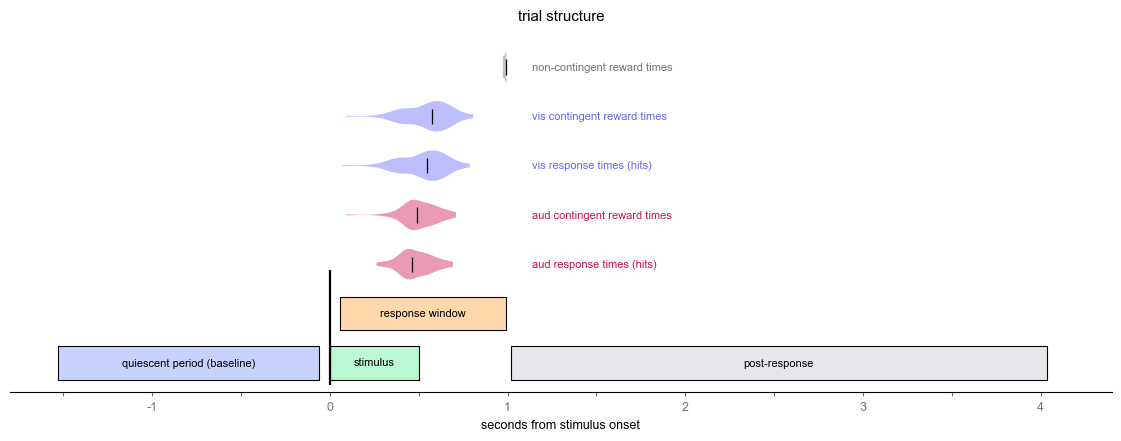

In [16]:
def median_relative_interval(
    trials: pl.DataFrame,
    start_col: str,
    stop_col: str,
) -> tuple[float, float] | None:
    relative = (
        trials.select(
            (pl.col(start_col) - pl.col("stim_start_time")).alias("start"),
            (pl.col(stop_col) - pl.col("stim_start_time")).alias("stop"),
        )
        .filter(
            pl.col("start").is_finite()
            & pl.col("stop").is_finite()
            & (pl.col("stop") > pl.col("start"))
        )
    )
    if relative.is_empty():
        return None

    start, stop = relative.select(pl.median("start"), pl.median("stop")).row(0)
    return float(start), float(stop)


def relative_event_times(
    trials: pl.DataFrame,
    time_col: str,
    trial_filter: pl.Expr,
) -> np.ndarray:
    return (
        trials.filter(
            trial_filter
            & pl.col(time_col).is_finite()
            & pl.col("stim_start_time").is_finite()
        )
        .select((pl.col(time_col) - pl.col("stim_start_time")).alias("time"))
        .filter(pl.col("time").is_finite())
    )["time"].to_numpy()


def plot_trial_structure(
    trials: pl.DataFrame,
    save_path: pathlib.Path | None = None,
) -> plt.Figure:
    intervals = [
        ("quiescent period (baseline)", "quiescent_start_time", "quiescent_stop_time", "#c7d2fe", 0),
        ("stimulus", "stim_start_time", "stim_stop_time", "#bbf7d0", 0),
        (
            "response window",
            "response_window_start_time",
            "response_window_stop_time",
            "#fed7aa",
            1,
        ),
        (
            "post-response",
            "post_response_window_start_time",
            "post_response_window_stop_time",
            "#e5e7eb",
            0,
        ),
    ]
    interval_row_count = 2
    event_distributions = [
        ("aud response times (hits)", "response_time", pl.col("is_aud_target") & pl.col("is_hit"), CONTEXT_COLORS["aud"]),
        (
            "aud contingent reward times",
            "reward_time",
            pl.col("is_aud_stim") & pl.col("is_contingent_reward"),
            CONTEXT_COLORS["aud"],
        ),
        ("vis response times (hits)", "response_time", pl.col("is_vis_target") & pl.col("is_hit"), CONTEXT_COLORS["vis"]),
        (
            "vis contingent reward times",
            "reward_time",
            pl.col("is_vis_stim") & pl.col("is_contingent_reward"),
            CONTEXT_COLORS["vis"],
        ),
        (
            "non-contingent reward times",
            "reward_time",
            pl.col("is_noncontingent_reward"),
            COLORS["gray2"],
        ),
    ]

    fig, ax = plt.subplots(figsize=(11.1, 4.3), constrained_layout=True)
    x_values = []
    for label, start_col, stop_col, color, row in intervals:
        interval = median_relative_interval(trials, start_col, stop_col)
        if interval is None:
            continue
        start, stop = interval
        x_values.extend([start, stop])
        ax.broken_barh(
            [(start, stop - start)],
            (row - 0.34, 0.68),
            facecolors=color,
            edgecolors=COLORS["black"],
            linewidth=0.8,
        )
        ax.text(
            (start + stop) / 2,
            row,
            label,
            ha="center",
            va="center",
            fontsize=8,
        )

    post_response_interval = median_relative_interval(
        trials,
        "post_response_window_start_time",
        "post_response_window_stop_time",
    )
    event_label_x = post_response_interval[0] if post_response_interval is not None else 1.0

    for offset, (label, time_col, trial_filter, color) in enumerate(event_distributions):
        row = interval_row_count + offset
        times = relative_event_times(trials, time_col, trial_filter)
        x_values.extend(times.tolist())
        ax.text(
            event_label_x + 0.12,
            row,
            label,
            ha="left",
            va="center",
            fontsize=8,
            color=color,
        )
        if len(times) >= 2:
            parts = ax.violinplot(
                [times],
                positions=[row],
                vert=False,
                widths=0.62,
                showextrema=False,
                showmedians=True,
            )
            for body in parts["bodies"]:
                body.set_facecolor(color)
                body.set_edgecolor(None)
                body.set_alpha(0.42)
                body.set_linewidth(0.8)
            parts["cmedians"].set_color(COLORS["black"])
            parts["cmedians"].set_linewidth(0.9)
        elif len(times) == 1:
            ax.scatter(times, [row], marker="|", s=42, color=color)

    ax.vlines(0, -0.45, interval_row_count - 0.12, color=COLORS["black"], lw=1.6)
    ax.set_yticks([])
    ax.set_xlabel("seconds from stimulus onset")
    ax.set_title("trial structure", pad=8)
    if x_values:
        ax.set_xlim(min(-1.8, min(x_values) - 0.25), max(4.4, max(x_values) + 0.25))
    else:
        ax.set_xlim(-1.8, 4.4)
    x_min, x_max = ax.get_xlim()
    tick_start = np.ceil(x_min * 2) / 2
    tick_stop = np.floor(x_max * 2) / 2
    xticks = np.arange(tick_start, tick_stop + 0.25, 0.5)
    ax.set_xticks(xticks)
    ax.set_xticklabels(
        [f"{tick:g}" if np.isclose(tick, round(tick)) else "" for tick in xticks]
    )
    ax.set_ylim(-0.6, interval_row_count + len(event_distributions) - 0.28)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="x", length=3)
    ax.tick_params(axis="y", left=False, labelleft=False)
    if save_path is not None:
        save_path = pathlib.Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    return fig


fig = plot_trial_structure(trials)
plt.show()


## Block structure

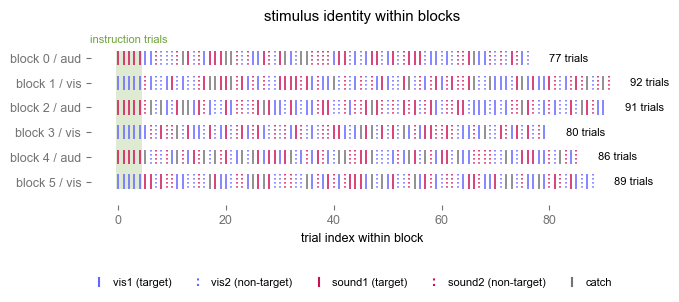

In [17]:
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase


class HandlerVerticalLine(HandlerBase):
    def create_artists(
        self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans
    ):
        x = xdescent + width / 2
        line = Line2D(
            [x, x],
            [ydescent, ydescent + height],
            color=orig_handle.get_color(),
            linestyle=orig_handle.get_linestyle(),
            linewidth=orig_handle.get_linewidth(),
            transform=trans,
        )
        return [line]


STIM_COLORS = {
    "vis1": CONTEXT_COLORS["vis"],
    "vis2": CONTEXT_COLORS["vis"],
    "sound1": CONTEXT_COLORS["aud"],
    "sound2": CONTEXT_COLORS["aud"],
    "catch": COLORS["gray2"],
}
STIM_LINESTYLES = {
    "vis1": "solid",
    "vis2": "dotted",
    "sound1": "solid",
    "sound2": "dotted",
    "catch": "solid",
}
stim_order = ["vis1", "vis2", "sound1", "sound2", "catch"]
instruction_color = "#6FA23A"
bar_height = 0.58

fig, ax = plt.subplots(figsize=(7, 2.8))


block_summary = (
    trials.group_by("block_index", "rewarded_modality")
    .agg(
        pl.len().alias("n_trials"),
        pl.col("is_instruction").sum().alias("n_instruction_trials"),
        pl.col("is_reward_scheduled").sum().alias("n_scheduled_rewards"),
        pl.col("is_noncontingent_reward").sum().alias("n_noncontingent_rewards"),
        pl.col("is_opto").sum().alias("n_opto_trials"),
        pl.col("start_time").min().alias("start_time"),
        pl.col("stop_time").max().alias("stop_time"),
    )
    .sort("block_index")
    .with_columns(duration_min=(pl.col("stop_time") - pl.col("start_time")) / 60)
)
instruction_y_min = block_summary["block_index"].min() - bar_height / 2
instruction_y_max = block_summary["block_index"].max() + bar_height / 2
ax.fill_betweenx(
    [instruction_y_min, instruction_y_max],
    -0.5,
    4.5,
    color=instruction_color,
    alpha=0.22,
    linewidth=0,
    zorder=0,
)

for row in block_summary.iter_rows(named=True):
    block = row["block_index"]
    n_trials = row["n_trials"]
    block_trials = trials.filter(pl.col("block_index") == block).sort(
        "trial_index_in_block"
    )

    for stim_name in stim_order:
        stim_x = block_trials.filter(pl.col("stim_name") == stim_name)[
            "trial_index_in_block"
        ].to_numpy()

        if len(stim_x):
            ax.vlines(
                stim_x,
                block - bar_height / 2,
                block + bar_height / 2,
                color=STIM_COLORS[stim_name],
                linestyles=STIM_LINESTYLES[stim_name],
                linewidth=1.1,
                zorder=1,
            )

    ax.text(n_trials + 3, block, f"{n_trials} trials", va="center", fontsize=8)

ax.set_yticks(block_summary["block_index"].to_list())
ax.set_yticklabels(
    [
        f"block {block} / {modality}"
        for block, modality in block_summary.select(
            "block_index", "rewarded_modality"
        ).iter_rows()
    ]
)
ax.invert_yaxis()
ax.annotate(
    "instruction trials",
    xy=(2, instruction_y_min),
    xytext=(2, instruction_y_min - 0.28),
    ha="center",
    va="bottom",
    fontsize=8,
    color=instruction_color,
    arrowprops={"arrowstyle": "-", "color": instruction_color, "linewidth": 0},
    annotation_clip=False,
)
ax.set_xlabel("trial index within block")
ax.set_title("stimulus identity within blocks", pad=10)
target_label = {
    "vis1": " (target)",
    "sound1": " (target)",
    "vis2": " (non-target)",
    "sound2": " (non-target)",
    "catch": "",
}
fig.legend(
    handles=[
        Line2D(
            [],
            [],
            color=STIM_COLORS[stim_name],
            linestyle=STIM_LINESTYLES[stim_name],
            linewidth=1.5,
            label=stim_name + target_label[stim_name],
        )
        for stim_name in stim_order
    ],
    # title="stimulus",
    frameon=False,
    fontsize=8,
    title_fontsize=8,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=len(stim_order),
    handler_map={Line2D: HandlerVerticalLine()},
    handlelength=0.8,
    borderaxespad=0,
)
ax.margins(y=0.12)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
fig.subplots_adjust(top=0.72)
plt.show()


---
# Behavioral performance
## Target response rate across blocks


block_index,rewarded_modality,stim_name,n_trials,n_responses,response_rate
i64,str,str,u32,u32,f64
0,"""aud""","""sound1""",16,16,1.0
1,"""vis""","""sound1""",19,0,0.0
2,"""aud""","""sound1""",18,18,1.0
3,"""vis""","""sound1""",18,3,0.166667
4,"""aud""","""sound1""",15,14,0.933333
5,"""vis""","""sound1""",17,2,0.117647
0,"""aud""","""vis1""",16,6,0.375
1,"""vis""","""vis1""",20,20,1.0
2,"""aud""","""vis1""",20,1,0.05


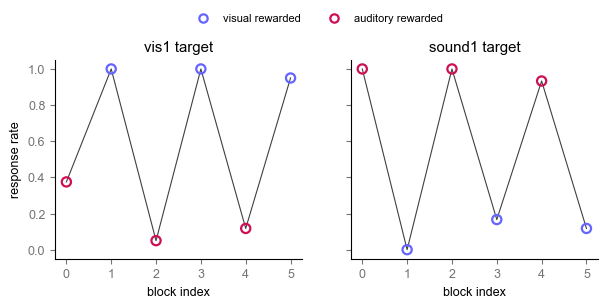

In [18]:
from matplotlib.lines import Line2D

target_response_rates = (
    trials.filter(
        pl.col("stim_name").is_in(["vis1", "sound1"]),
        ~pl.col("is_instruction"),
        ~pl.col("is_reward_scheduled"),
    )
    .group_by("block_index", "rewarded_modality", "stim_name")
    .agg(
        pl.len().alias("n_trials"),
        pl.col("is_response").sum().alias("n_responses"),
    )
    .with_columns(response_rate=pl.col("n_responses") / pl.col("n_trials"))
    .sort(["stim_name", "block_index"])
)

fig, axes = plt.subplots(1, 2, figsize=(7, 2.8), sharey=True)

for ax, stim_name, title in zip(
    axes, ["vis1", "sound1"], ["vis1 target", "sound1 target"]
):
    data = target_response_rates.filter(pl.col("stim_name") == stim_name)
    ax.plot(data["block_index"], data["response_rate"], color="0.25", linewidth=0.8)
    for row in data.iter_rows(named=True):
        ax.scatter(
            row["block_index"],
            row["response_rate"],
            marker="o",
            s=44,
            facecolors="none",
            edgecolors=CONTEXT_COLORS[row["rewarded_modality"]],
            linewidths=1.6,
            zorder=2,
        )
    ax.set_title(title)
    ax.set_xlabel("block index")
    ax.set_xticks(block_summary["block_index"].to_list())
    ax.set_ylim(-0.05, 1.05)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("response rate")
fig.legend(
    handles=[
        Line2D(
            [],
            [],
            marker="o",
            linestyle="none",
            markerfacecolor="none",
            markeredgecolor=CONTEXT_COLORS["vis"],
            markeredgewidth=1.6,
            markersize=6,
            label="visual rewarded",
        ),
        Line2D(
            [],
            [],
            marker="o",
            linestyle="none",
            markerfacecolor="none",
            markeredgecolor=CONTEXT_COLORS["aud"],
            markeredgewidth=1.6,
            markersize=6,
            label="auditory rewarded",
        ),
    ],
    frameon=False,
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
)
fig.subplots_adjust(top=0.82)

display(target_response_rates)
plt.show()


### Performance table

`/intervals/performance` provides richer block-level behavior metrics, including d' values and response rates for targets and non-targets.


In [19]:
performance = (
    nwb_access.scan_table("/intervals/performance", session_id=SESSION_ID)
    .select(
        [
            "block_index",
            "rewarded_modality",
            "n_trials",
            "n_contingent_rewards",
            "hit_rate",
            "false_alarm_rate",
            "cross_modality_dprime",
            "vis_target_response_rate",
            "aud_target_response_rate",
            "vis_dprime",
            "aud_dprime",
        ]
    )
    .collect()
    .sort("block_index")
)

performance


block_index,rewarded_modality,n_trials,n_contingent_rewards,hit_rate,false_alarm_rate,cross_modality_dprime,vis_target_response_rate,aud_target_response_rate,vis_dprime,aud_dprime
i64,str,i64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""aud""",77,21.0,1.0,0.428571,2.299392,0.375,1.0,-0.298005,0.830403
1,"""vis""",92,24.0,0.96,0.035088,3.688618,1.0,0.0,3.665192,-0.65638
2,"""aud""",91,22.0,0.956522,0.133333,3.356529,0.05,1.0,0.0,2.096996
3,"""vis""",80,21.0,0.954545,0.075472,2.658043,1.0,0.166667,3.28384,-0.024996
4,"""aud""",86,18.0,0.9,0.058824,2.468383,0.117647,0.933333,-0.026778,2.87477
5,"""vis""",89,23.0,0.92,0.037037,2.591903,0.95,0.117647,3.343003,0.024996


---
# Neural data
## Brain areas recorded

In [20]:
unit_metadata = (
    nwb_access.scan_table("/units", session_id=SESSION_ID)
    .select("structure", "unit_id", "is_qc_pass")
    .collect()
)

In [21]:
tbl = (
    unit_metadata
    .group_by("structure")
    .agg(
        pl.len().alias("units"),
        pl.col("unit_id").filter("is_qc_pass").len().alias("passing qc"),
    )
    .sort("units", descending=True)
    .join(
        pl.read_csv("https://raw.githubusercontent.com/cortex-lab/allenCCF/refs/heads/master/structure_tree_safe_2017.csv").select("name", "acronym"),
        left_on="structure",
        right_on="acronym",
    )
    .sort("structure")
    .select(pl.col("name").alias("description"), pl.col("structure").alias("structure (acronym)"), pl.col("units").alias("n units"), pl.col("passing qc").alias("n passing qc"))
)
with pl.Config(
    tbl_rows=-1,          # all rows
    tbl_cols=-1,          # all columns, if needed
    tbl_width_chars=-1,   # full table width
    fmt_str_lengths=80,   # wider string columns
):
    display(tbl)

description,structure (acronym),n units,n passing qc
str,str,u32,u32
"""Anterior cingulate area dorsal part""","""ACAd""",19,1
"""Anterodorsal nucleus""","""AD""",130,5
"""Primary auditory area""","""AUDp""",201,87
"""Posterior auditory area""","""AUDpo""",55,18
"""Ventral auditory area""","""AUDv""",176,62
"""Anteroventral nucleus of thalamus""","""AV""",30,5
"""Caudoputamen""","""CP""",288,105
"""Ectorhinal area""","""ECT""",282,168
"""Lateral septal nucleus caudal (caudodorsal) part""","""LSc""",47,18


In [22]:
# CCF coordinates are stored in microns; convert to millimeters for plotting.
ccf_coordinate_cols = ["ccf_ap", "ccf_ml", "ccf_dv"]

unit_ccf = (
    nwb_access.scan_table("/units", session_id=SESSION_ID)
    .select("structure", "unit_id", "is_qc_pass", "ccf_ap", "ccf_ml", "ccf_dv", "electrode_group_name")
    .collect()
    .with_columns(pl.col(ccf_coordinate_cols) / 1000)
)

In [23]:
import altair as alt

tooltip_cols = ["structure", "unit_id", "is_qc_pass", "electrode_group_name"]
ccf_colors = (
    pl.read_csv("https://raw.githubusercontent.com/cortex-lab/allenCCF/refs/heads/master/structure_tree_safe_2017.csv")
    .select("acronym", "color_hex_triplet")
    .unique("acronym")
)

color_map = (
    unit_ccf
    .select("structure")
    .unique()
    .join(ccf_colors, left_on="structure", right_on="acronym", how="left")
    .with_columns(
        ("#" + pl.col("color_hex_triplet").fill_null("999999")).alias("color_hex_triplet")
    )
    .sort("structure")
)
domain = color_map["structure"].to_list()
color_range = color_map["color_hex_triplet"].to_list()
color_scale = alt.Scale(domain=domain, range=color_range)


def padded_domain(values, padding=0.1, min_span=None):
    min_value = float(values.min()) - padding
    max_value = float(values.max()) + padding
    if min_span is not None and max_value - min_value < min_span:
        center = (min_value + max_value) / 2
        min_value = center - min_span / 2
        max_value = center + min_span / 2
    return [min_value, max_value]


pixels_per_mm = 65
ccf_ap_domain = padded_domain(unit_ccf["ccf_ap"], min_span=2.0)
ccf_ml_domain = padded_domain(unit_ccf["ccf_ml"], min_span=2.0)
ccf_dv_domain = padded_domain(unit_ccf["ccf_dv"])


def domain_pixels(domain):
    return max(1, round((domain[1] - domain[0]) * pixels_per_mm))


axis_gap = "\u00a0" * 20
x_axis_ap = alt.Axis(title=f"← anterior{axis_gap}(mm){axis_gap}posterior →")
x_axis_ml = alt.Axis(title=f"← medial{axis_gap}(mm){axis_gap}lateral →")
y_axis_dv = alt.Axis(title=f"← dorsal{axis_gap}(mm){axis_gap}ventral →")

base_ccf_chart = (
    alt.Chart(unit_ccf)
    .mark_point()
    .encode(
        tooltip=tooltip_cols,
        color=alt.Color("structure", scale=color_scale, legend=None),
    )
)

ap_projection = base_ccf_chart.encode(
    x=alt.X("ccf_ap", axis=x_axis_ap, scale=alt.Scale(domain=ccf_ap_domain, nice=False)),
    y=alt.Y("ccf_dv", axis=y_axis_dv, scale=alt.Scale(domain=ccf_dv_domain, nice=False, reverse=True)),
).properties(
    width=domain_pixels(ccf_ap_domain),
    height=domain_pixels(ccf_dv_domain),
)

ml_projection = base_ccf_chart.encode(
    x=alt.X("ccf_ml", axis=x_axis_ml, scale=alt.Scale(domain=ccf_ml_domain, nice=False, reverse=True)),
    y=alt.Y("ccf_dv", axis=y_axis_dv, scale=alt.Scale(domain=ccf_dv_domain, nice=False, reverse=True)),
).properties(
    width=domain_pixels(ccf_ml_domain),
    height=domain_pixels(ccf_dv_domain),
)

(
    ap_projection | ml_projection
).properties(title="Allen CCF coordinates of Neuropixels recording sites")

alt.HConcatChart(...)

## Single-unit exploration


### Metadata for a single unit

In [24]:
unit_metadata = (
    nwb_access.scan_table("/units", unit_id=UNIT_ID, exclude_array_columns=True)
    .filter(pl.col("unit_id") == UNIT_ID)
    .select(
        [
            "unit_id",
            "location",
            "electrode_group_name",
            "is_qc_pass",
            "is_not_drift",
            "activity_drift",
            "firing_rate",
            "num_spikes",
        ]
    )
    .collect()
)

unit_metadata


unit_id,location,electrode_group_name,is_qc_pass,is_not_drift,activity_drift,firing_rate,num_spikes
str,str,str,bool,bool,f64,f64,f64
"""713655_2024-08-09_E-167""","""CP""","""probeE""",true,true,0.05162,1.379626,10569.0


### Accessing spike times

In [25]:
spike_times_df = (
    nwb_access.scan_table("/units", unit_id=UNIT_ID, exclude_array_columns=False)
    .filter(pl.col("unit_id") == UNIT_ID)
    .select("spike_times")
    .collect()
)
spike_times = spike_times_df["spike_times"][0].to_numpy()
spike_times

array([  22.91027109,   47.21370617,  123.67631574, ..., 7649.92748527,
       7679.93094051, 7680.27723769], shape=(10569,))

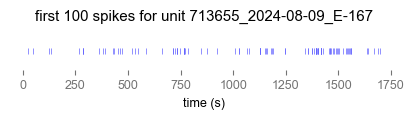

In [26]:
n_spikes_to_plot = 100
plt.eventplot(
    spike_times[:n_spikes_to_plot], 
    lineoffsets=0, 
    colors=COLORS["blue"], 
    linewidths=0.5,
    linelengths=1,
)

plt.gca().set_yticks([])
plt.ylim(-3, 3)
plt.gca().spines[["top", "right", "left", "bottom"]].set_visible(False)
plt.gca().set_xlabel("time (s)")
plt.gcf().set_size_inches(5, .5)
plt.title(f"first {n_spikes_to_plot} spikes for unit {UNIT_ID}", pad=8)
plt.show()

### Stimulus-aligned response (PSTH)

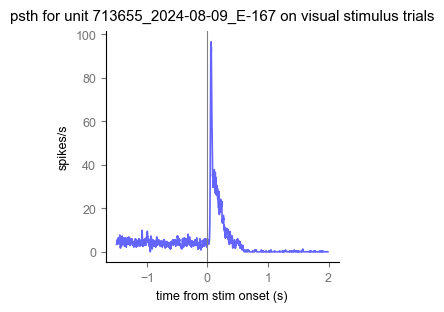

In [27]:
import polars_vec_ops as vec

xmin = -1.5
xmax = 2.0
bin_size = 0.001
smooth_bins = 10

vis_trials = trials.filter(
    pl.col("is_vis_stim"),
    pl.col("stim_start_time").is_finite(),
    ~pl.col("is_opto").fill_null(False),
    # ~pl.col("is_instruction"),  # consider excluding these too
)

per_trial_counts = (
    spike_times_df.vec.join_between(
        other=vis_trials,
        values="spike_times",
        bounds=(pl.col("stim_start_time") + xmin, pl.col("stim_start_time") + xmax),
        relative=True,
    )
    # convert from "relative to window start" back to "relative to stim onset"
    .with_columns(
        stim_rel_spike_times=pl.col("spike_times").list.eval(pl.element() + xmin)
    )
    .select(
        counts=pl.col("stim_rel_spike_times").vec.histogram(
            start=xmin,
            stop=xmax,
            spacing=bin_size,
        )
    )
)

psth_hz = (
    per_trial_counts
    .select(
        psth=(
            pl.col("counts")
            .vec.mean()
            .vec.convolve(
                kernel=np.ones(smooth_bins).tolist(), 
                mode="valid",
            )
            .truediv(smooth_bins * bin_size)
        )
    )
)["psth"][0].to_numpy()

t = xmin + np.arange(len(psth_hz)) * bin_size

plt.plot(t, psth_hz, c=COLORS["blue"], lw=1.2)
plt.axvline(0, color="gray", lw=0.8)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.xlabel("time from stim onset (s)")
plt.ylabel("spikes/s")
plt.gcf().set_size_inches(3, 3)
plt.title(f"psth for unit {UNIT_ID} on visual stimulus trials", pad=8)
plt.show()


## Activity by stimulus and block

Data loading took 2.54 seconds


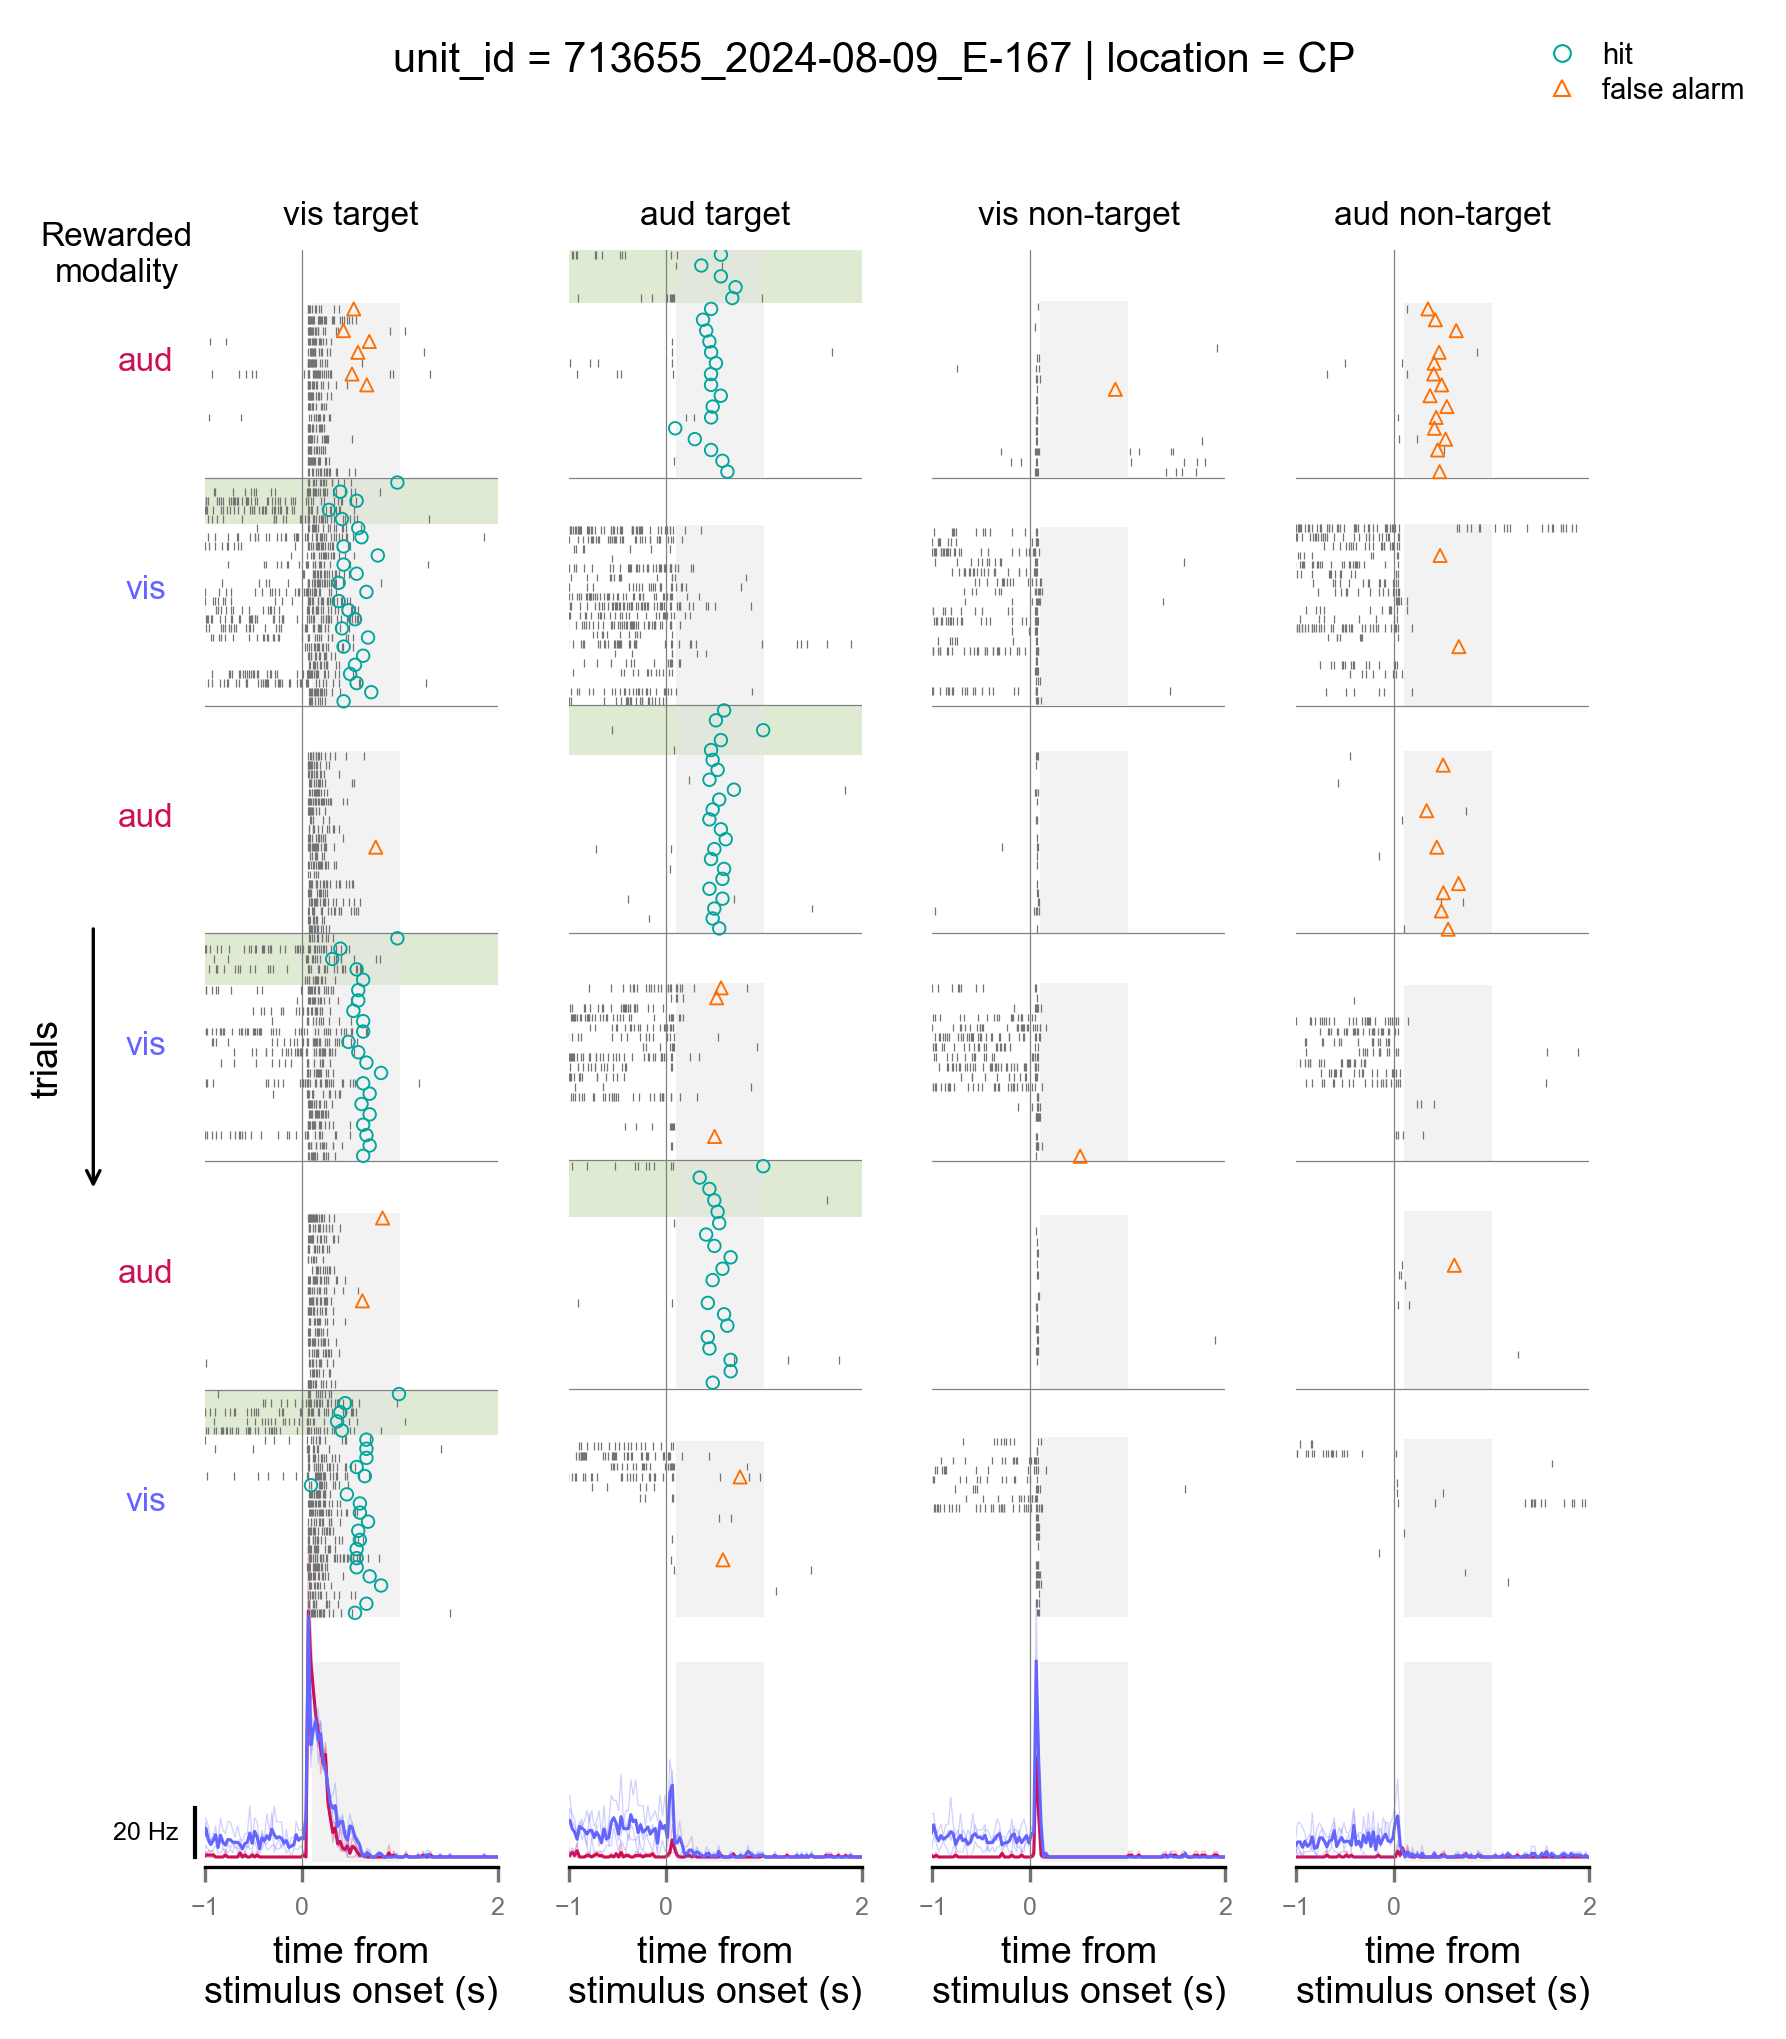

In [28]:
config = {
    "668755_2023-08-31_B-68": dict(
        max_psth_spike_rate=20,
    ),
    "668755_2023-08-31_B-213": dict(
        max_psth_spike_rate=60,
    ),
    "713655_2024-08-09_E-167": dict(
        max_psth_spike_rate=80,
    ),
}
fig = unit_raster_psth_plot.plot(
    UNIT_ID,
    **config[UNIT_ID],
    stim_names=("vis1", "sound1", "vis2", "sound2"),
    with_instruction_trial_whitespace=True,
    rewarded_context_colors=CONTEXT_COLORS,
    show_event_marker_legend=True,
    zarr=USE_ZARR,
)
plt.show()


---
# Behavioral data

## Accessing timeseries containers


In [29]:
running_speed = lazynwb.get_timeseries(session_nwb_path, "/processing/behavior/running_speed")
display(running_speed.timestamps, running_speed.data)

<zarr.core.Array '/processing/behavior/running_speed/timestamps' (447531,) float64 read-only>

<zarr.core.Array '/processing/behavior/running_speed/data' (447531,) float64 read-only>

In [30]:
sampling_rate_hz = 1 / np.median(np.diff(running_speed.timestamps[:1000]))
sampling_rate_hz 

np.float64(59.95203836930126)

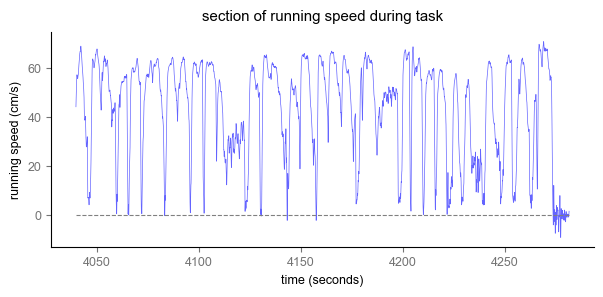

In [31]:
n_samples_to_plot = int(sampling_rate_hz * 60 * 4)
start_sample = int(sampling_rate_hz * 60 * 65)
plt.plot(
    running_speed.timestamps[start_sample:start_sample + n_samples_to_plot],
    running_speed.data[start_sample:start_sample + n_samples_to_plot],
    lw=0.5,
    c=COLORS["blue"],
)
plt.hlines(0, running_speed.timestamps[start_sample], running_speed.timestamps[start_sample + n_samples_to_plot], colors="gray", linestyles="dashed", linewidth=0.8)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.xlabel(f"time ({running_speed.timestamps_unit})")
plt.ylabel(f"running speed ({running_speed.unit})")
plt.gcf().set_size_inches(7, 2.8)
plt.title("section of running speed during task", pad=8);

## Running speed by outcome and block

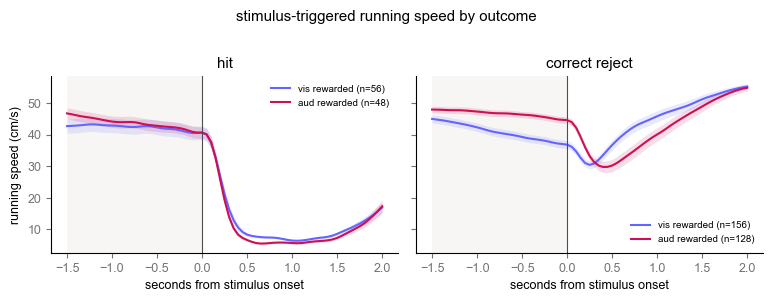

In [32]:
def align_signal_to_trials(
    signal: pl.DataFrame,
    *,
    time_column: str,
    value_column: str,
    value_name: str,
    trials_to_align: pl.DataFrame,
    time_grid: np.ndarray,
) -> list[dict]:
    signal = signal.filter(
        pl.col(time_column).is_not_null(),
        pl.col(value_column).is_not_null(),
        pl.col(time_column).is_finite(),
        pl.col(value_column).is_finite(),
    ).sort(time_column)
    signal_times = signal[time_column].to_numpy()
    signal_values = signal[value_column].to_numpy()

    aligned_rows = []
    for trial in trials_to_align.iter_rows(named=True):
        sample_times = trial["stim_start_time"] + time_grid
        if sample_times[0] < signal_times[0] or sample_times[-1] > signal_times[-1]:
            continue
        aligned_rows.append(
            {
                "rewarded_modality": trial["rewarded_modality"],
                "outcome": trial["outcome"],
                value_name: np.interp(sample_times, signal_times, signal_values),
            }
        )
    return aligned_rows


def plot_aligned_signal_by_outcome_columns(
    aligned_rows: list[dict],
    *,
    value_name: str,
    ylabel: str,
    title: str,
    time_grid: np.ndarray,
):
    xmin = time_grid[0]
    fig, axes = plt.subplots(1, 2, figsize=(7.8, 2.9), sharex=True, sharey=True)
    outcome_columns = [("hit", "hit"), ("correct reject", "correct reject")]

    for col_idx, (outcome, outcome_label) in enumerate(outcome_columns):
        ax = axes[col_idx]
        for rewarded_modality in ["vis", "aud"]:
            traces_for_group = [
                row[value_name]
                for row in aligned_rows
                if row["outcome"] == outcome
                and row["rewarded_modality"] == rewarded_modality
            ]
            if not traces_for_group:
                continue
            traces = np.vstack(traces_for_group)
            mean = traces.mean(axis=0)
            sem = (
                traces.std(axis=0, ddof=1) / np.sqrt(traces.shape[0])
                if traces.shape[0] > 1
                else np.zeros_like(mean)
            )
            color = CONTEXT_COLORS[rewarded_modality]
            ax.plot(
                time_grid,
                mean,
                color=color,
                label=f"{rewarded_modality} rewarded (n={traces.shape[0]})",
            )
            ax.fill_between(
                time_grid,
                mean - sem,
                mean + sem,
                color=color,
                alpha=0.14,
                linewidth=0,
            )

        ax.axvspan(xmin, 0, color=COLORS["page2"], alpha=0.22, linewidth=0, zorder=0)
        ax.axvline(0, color="0.3", linewidth=0.8)
        ax.set_title(outcome_label)
        ax.set_xlabel("seconds from stimulus onset")
        ax.spines[["top", "right"]].set_visible(False)
        if col_idx == 0:
            ax.set_ylabel(ylabel)
        ax.legend(frameon=False, fontsize=7, loc="best")

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    return fig


running_time_grid = np.arange(-1.5, 2.01, 0.05)

running_trials_by_context = (
    trials.filter(
        pl.col("stim_start_time").is_finite(),
        ~pl.col("is_instruction"),
        pl.col("stim_name") != "catch",
        pl.col("is_hit") | pl.col("is_correct_reject"),
    )
    .with_columns(
        pl.when(pl.col("is_hit"))
        .then(pl.lit("hit"))
        .otherwise(pl.lit("correct reject"))
        .alias("outcome")
    )
    .select(["trial_index", "rewarded_modality", "outcome", "stim_start_time"])
)

running = (
    nwb_access.scan_table("/processing/behavior/running_speed", session_id=SESSION_ID)
    .select(["timestamps", "data"])
    .collect()
)

running_aligned_rows = align_signal_to_trials(
    running,
    time_column="timestamps",
    value_column="data",
    value_name="running_speed",
    trials_to_align=running_trials_by_context,
    time_grid=running_time_grid,
)

plot_aligned_signal_by_outcome_columns(
    running_aligned_rows,
    value_name="running_speed",
    ylabel=f"running speed ({running_speed.unit})",
    title="stimulus-triggered running speed by outcome",
    time_grid=running_time_grid,
)
plt.show()


## Facial features from `lightning pose (lp)` 

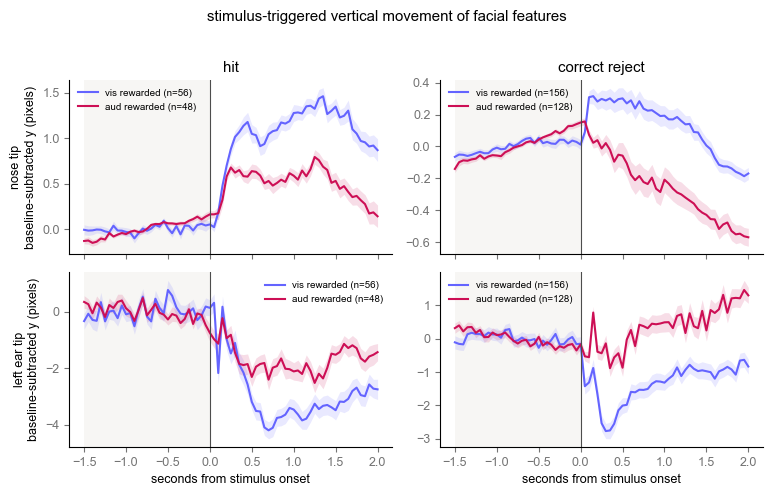

In [33]:
xmin = -1.5
pose_time_grid = np.arange(xmin, 2.01, 0.05)
pose_baseline_mask = (pose_time_grid >= xmin) & (pose_time_grid < 0)

pose_trials_by_context = (
    trials.filter(
        pl.col("stim_start_time").is_finite(),
        ~pl.col("is_instruction"),
        pl.col("stim_name") != "catch",
        pl.col("is_hit") | pl.col("is_correct_reject"),
    )
    .with_columns(
        pl.when(pl.col("is_hit"))
        .then(pl.lit("hit"))
        .otherwise(pl.lit("correct reject"))
        .alias("outcome")
    )
    .select(["trial_index", "rewarded_modality", "outcome", "stim_start_time"])
)

lp_side_frame_times = (
    nwb_access.scan_table("/acquisition/frametimes_side_camera", session_id=SESSION_ID)
    .select("timestamps")
    .collect()
)
lp_side_pose_measurements = (
    nwb_access.scan_table("/processing/behavior/lp_side_camera", session_id=SESSION_ID)
    .select(["nose_tip_y", "ear_tip_l_y"])
    .collect()
)
lp_side_pose_by_context = lp_side_frame_times.hstack(lp_side_pose_measurements).filter(
    pl.col("timestamps").is_finite()
)


def align_pose_coordinate_to_context(
    pose: pl.DataFrame,
    coordinate: str,
) -> list[dict]:
    signal = pose.filter(
        pl.col(coordinate).is_not_null(),
        pl.col(coordinate).is_finite(),
    ).sort("timestamps")
    signal_times = signal["timestamps"].to_numpy()
    signal_values = signal[coordinate].to_numpy()

    aligned_rows = []
    for trial in pose_trials_by_context.iter_rows(named=True):
        sample_times = trial["stim_start_time"] + pose_time_grid
        if sample_times[0] < signal_times[0] or sample_times[-1] > signal_times[-1]:
            continue
        values = np.interp(sample_times, signal_times, signal_values)
        aligned_rows.append(
            {
                "rewarded_modality": trial["rewarded_modality"],
                "outcome": trial["outcome"],
                "values": values - values[pose_baseline_mask].mean(),
            }
        )
    return aligned_rows


fig, axes = plt.subplots(2, 2, figsize=(7.8, 4.8), sharex=True)
bodyparts = [("nose_tip", "nose tip"), ("ear_tip_l", "left ear tip")]
outcome_columns = [("hit", "hit"), ("correct reject", "correct reject")]

for row_idx, (bodypart, bodypart_label) in enumerate(bodyparts):
    aligned_rows = align_pose_coordinate_to_context(
        lp_side_pose_by_context,
        f"{bodypart}_y",
    )
    for col_idx, (outcome, outcome_label) in enumerate(outcome_columns):
        ax = axes[row_idx, col_idx]
        for rewarded_modality in ["vis", "aud"]:
            traces_for_group = [
                row["values"]
                for row in aligned_rows
                if row["outcome"] == outcome
                and row["rewarded_modality"] == rewarded_modality
            ]
            if not traces_for_group:
                continue
            traces = np.vstack(traces_for_group)
            mean = traces.mean(axis=0)
            sem = (
                traces.std(axis=0, ddof=1) / np.sqrt(traces.shape[0])
                if traces.shape[0] > 1
                else np.zeros_like(mean)
            )
            color = CONTEXT_COLORS[rewarded_modality]
            ax.plot(
                pose_time_grid,
                mean,
                color=color,
                label=f"{rewarded_modality} rewarded (n={traces.shape[0]})",
            )
            ax.fill_between(
                pose_time_grid,
                mean - sem,
                mean + sem,
                color=color,
                alpha=0.14,
                linewidth=0,
            )

        ax.axvspan(xmin, 0, color=COLORS["page2"], alpha=0.22, linewidth=0, zorder=0)
        ax.axvline(0, color="0.3", linewidth=0.8)
        ax.spines[["top", "right"]].set_visible(False)
        if row_idx == 0:
            ax.set_title(outcome_label)
        if row_idx == 1:
            ax.set_xlabel("seconds from stimulus onset")
        if col_idx == 0:
            ax.set_ylabel(f"{bodypart_label}\nbaseline-subtracted y (pixels)")
        ax.legend(frameon=False, fontsize=7, loc="best")

fig.suptitle("stimulus-triggered vertical movement of facial features", y=1.02)
fig.tight_layout()
plt.show()
